In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [4]:
import our_steady_state_model as ss

Internal RH:  0.17242505971266292
Building heat loss:  709.1956521739131
Wall temperature (F):  65.62926024844717

Heat loss of user (watts):  69.4420056511378
Verdict:  Good

Internal RH:  0.15042791978650996
Building heat loss:  787.9951690821259
Wall temperature (F):  69.36584472049695

Heat loss of user (watts):  59.86750303131723
Verdict:  Good

Internal RH:  0.13154044151835576
Building heat loss:  866.7946859903386
Wall temperature (F):  73.10242919254664

Heat loss of user (watts):  50.153339249933424
Verdict:  Good

Internal RH:  0.0664313854131188
Building heat loss:  1113.4371739130427
Wall temperature (F):  64.2779385900621

Heat loss of user (watts):  72.03771095434932
Verdict:  Cold

Internal RH:  0.057956396436135114
Building heat loss:  1192.2366908212557
Wall temperature (F):  68.01452306211179

Heat loss of user (watts):  62.440051730775735
Verdict:  Good

Internal RH:  0.050679488135192186
Building heat loss:  1271.0362077294683
Wall temperature (F):  71.751107534161

In [5]:
df = pd.read_csv("Weather and Temperature Logs(February 2026).csv")
df.head()

,Time Stamp,Current Weather,Temp (C),Humidity,Barometric Pressue (Pa),Wind Direction,Wind Speed (m/s),Wind Chill (C),Heat Index (C)
0,2/1/2026 0:15:00,Cloudy,-11.4,60.644017,101420.0,320.0,14.76,-18.385102,NaN
1,2/1/2026 0:35:00,Mostly Cloudy,-11.5,61.647019,101390.0,310.0,9.36,-16.787109,NaN
2,2/1/2026 0:55:00,Clear,-11.6,61.620911,101320.0,310.0,22.32,-20.310614,NaN
3,2/1/2026 1:15:00,Clear,-12.1,64.140316,101360.0,320.0,16.56,-19.708570,NaN
4,2/1/2026 1:35:00,Clear,-12.3,64.090342,101390.0,310.0,12.96,-18.978616,NaN


In [6]:
# Wind direction is probably not needed, heat index column is mostly empty
df = df.drop("Wind Direction", axis=1)
df = df.drop("Heat Index (C)", axis=1)

In [7]:
df.head()

,Time Stamp,Current Weather,Temp (C),Humidity,Barometric Pressue (Pa),Wind Speed (m/s),Wind Chill (C)
0,2/1/2026 0:15:00,Cloudy,-11.4,60.644017,101420.0,14.76,-18.385102
1,2/1/2026 0:35:00,Mostly Cloudy,-11.5,61.647019,101390.0,9.36,-16.787109
2,2/1/2026 0:55:00,Clear,-11.6,61.620911,101320.0,22.32,-20.310614
3,2/1/2026 1:15:00,Clear,-12.1,64.140316,101360.0,16.56,-19.708570
4,2/1/2026 1:35:00,Clear,-12.3,64.090342,101390.0,12.96,-18.978616


In [8]:
# Our reference values
R_wall = 2.3
A_envelope = 70
ACH = 0.5
volume = 30

In [9]:
df["R_wall"] = R_wall
df["A_envelope"] = A_envelope
df["ACH"] = ACH
df["volume"] = volume

In [10]:
df.head()

,Time Stamp,Current Weather,Temp (C),Humidity,Barometric Pressue (Pa),Wind Speed (m/s),Wind Chill (C),R_wall,A_envelope,ACH,volume
0,2/1/2026 0:15:00,Cloudy,-11.4,60.644017,101420.0,14.76,-18.385102,2.3,70,0.5,30
1,2/1/2026 0:35:00,Mostly Cloudy,-11.5,61.647019,101390.0,9.36,-16.787109,2.3,70,0.5,30
2,2/1/2026 0:55:00,Clear,-11.6,61.620911,101320.0,22.32,-20.310614,2.3,70,0.5,30
3,2/1/2026 1:15:00,Clear,-12.1,64.140316,101360.0,16.56,-19.708570,2.3,70,0.5,30
4,2/1/2026 1:35:00,Clear,-12.3,64.090342,101390.0,12.96,-18.978616,2.3,70,0.5,30


In [11]:
# Conversions
df["Temp (C)"] = ss.c_to_f(df["Temp (C)"])
df["Wind Chill (C)"] = df["Wind Chill (C)"]*(9/5)
df["Humidity"] = df["Humidity"] / 100
df = df.rename(columns={"Temp (C)":"Temp (F)", "Wind Chill (C)":"Wind Chill (F)"})

In [12]:
df.head()

,Time Stamp,Current Weather,Temp (F),Humidity,Barometric Pressue (Pa),Wind Speed (m/s),Wind Chill (F),R_wall,A_envelope,ACH,volume
0,2/1/2026 0:15:00,Cloudy,11.48,0.606440,101420.0,14.76,-33.093184,2.3,70,0.5,30
1,2/1/2026 0:35:00,Mostly Cloudy,11.30,0.616470,101390.0,9.36,-30.216796,2.3,70,0.5,30
2,2/1/2026 0:55:00,Clear,11.12,0.616209,101320.0,22.32,-36.559105,2.3,70,0.5,30
3,2/1/2026 1:15:00,Clear,10.22,0.641403,101360.0,16.56,-35.475425,2.3,70,0.5,30
4,2/1/2026 1:35:00,Clear,9.86,0.640903,101390.0,12.96,-34.161509,2.3,70,0.5,30


In [13]:
# For now assume set temp is 72 F
df["User Heat Loss"] = None
df["Verdict"] = None
df["Internal Humidity"] = None
df["Building Heat Loss"] = None
df["Wall Temp (F)"] = None
for i in range(len(df)):
    user_q_total, verdict, RH_internal, Q_total, T_wall_F = ss.steady_state_model(72, df.at[i, "Temp (F)"], df.at[i, "Humidity"], print_output=False)
    df.at[i, "User Heat Loss"] = user_q_total
    df.at[i, "Verdict"] = verdict
    df.at[i, "Internal Humidity"] = RH_internal
    df.at[i, "Building Heat Loss"] = Q_total
    df.at[i, "Wall Temp (F)"] = T_wall_F


In [14]:
df.head()

,Time Stamp,Current Weather,Temp (F),Humidity,Barometric Pressue (Pa),Wind Speed (m/s),Wind Chill (F),R_wall,A_envelope,ACH,volume,User Heat Loss,Verdict,Internal Humidity,Building Heat Loss,Wall Temp (F)
0,2/1/2026 0:15:00,Cloudy,11.48,0.606440,101420.0,14.76,-33.093184,2.3,70,0.5,30,62.440033,Good,0.05796,1192.236691,68.014523
1,2/1/2026 0:35:00,Mostly Cloudy,11.30,0.616470,101390.0,9.36,-30.216796,2.3,70,0.5,30,62.456026,Good,0.058449,1195.782669,68.002669
2,2/1/2026 0:55:00,Clear,11.12,0.616209,101320.0,22.32,-36.559105,2.3,70,0.5,30,62.476918,Good,0.057958,1199.328647,67.990816
3,2/1/2026 1:15:00,Clear,10.22,0.641403,101360.0,16.56,-35.475425,2.3,70,0.5,30,62.569111,Good,0.057954,1217.058539,67.931547
4,2/1/2026 1:35:00,Clear,9.86,0.640903,101390.0,12.96,-34.161509,2.3,70,0.5,30,62.610823,Good,0.056983,1224.150495,67.90784


Not sure yet if we will use current weather, barometric pressure, wind speed, or wind chill.

Dropping constant columns:
['bld_r_wall', 'bld_a_envelope', 'bld_ach', 'bld_volume']
Train rows: 4,960
Test rows: 1,241
Train class distribution:
tgt_comfort_label
Good    3678
Cold     885
Hot      397
Name: count, dtype: int64
Test class distribution:
tgt_comfort_label
Good    921
Cold    221
Hot      99
Name: count, dtype: int64

Accuracy: 0.9992
Macro F1: 0.9991
Weighted F1: 0.9992

Classification report:
              precision    recall  f1-score   support

        Cold       1.00      1.00      1.00       221
        Good       1.00      1.00      1.00       921
         Hot       1.00      1.00      1.00        99

    accuracy                           1.00      1241
   macro avg       1.00      1.00      1.00      1241
weighted avg       1.00      1.00      1.00      1241



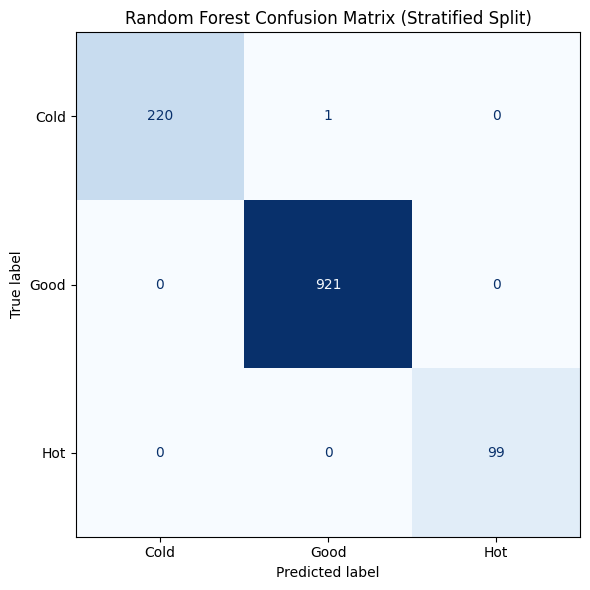

Top 20 feature importances:
wx_rh_percent                 1.455003e-01
msr_indoor_rh_percent         1.197825e-01
msr_indoor_rh_frac            1.124638e-01
phy_wall_temp_f               1.056538e-01
wx_temp_c                     1.017685e-01
msr_indoor_temp_f             8.914650e-02
phy_user_heat_loss_wm2        8.654568e-02
msr_wall_temp_f               6.676000e-02
phy_indoor_rh_frac            6.252783e-02
phy_building_heat_loss_w      4.285956e-02
msr_ambient2_temp_f           4.037386e-02
wx_condition_Clear            8.211722e-03
wx_condition_Mostly Cloudy    6.782390e-03
phy_verdict_Cold              5.962670e-03
phy_verdict_Good              3.469104e-03
meta_weather_gap_minutes      2.087053e-03
wx_condition_Partly Cloudy    1.048092e-04
wx_condition_Light Snow       3.828833e-16
wx_condition_Cloudy           2.342029e-16
dtype: float64

Run summary:
{
  "split": "stratified_80_20",
  "train_rows": 4960,
  "test_rows": 1241,
  "accuracy": 0.9991941982272361,
  "macro_f1": 0.

In [15]:
# goal: train a first-pass Random Forest classifier on the combined dataset.

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
 )
from sklearn.model_selection import train_test_split

# 1) loading the combined dataset.
base = Path.cwd()
dataset_path = base / "rf_combined_dataset.csv"
df = pd.read_csv(dataset_path)

# 2) standardize target label text to avoid inconsistencies.
df = df.copy()
df["tgt_comfort_label"] = (
    df["tgt_comfort_label"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({"Comfort": "Good"})
)

# 3) drop columns with zero variance so only informative features remain.
constant_cols = [
    col for col in df.columns
    if col != "tgt_comfort_label" and df[col].nunique(dropna=False) <= 1
]
if constant_cols:
    print("Dropping constant columns:")
    print(constant_cols)
df = df.drop(columns=constant_cols)

# 4) parse timestamps for QC/analysis, but exclude them from model features to prevent leakage.
if "meta_comfort_timestamp" in df.columns:
    df["meta_comfort_timestamp"] = pd.to_datetime(df["meta_comfort_timestamp"], errors="coerce")
if "meta_weather_timestamp" in df.columns:
    df["meta_weather_timestamp"] = pd.to_datetime(df["meta_weather_timestamp"], errors="coerce")

# 5) build target and candidate feature sets.
target_col = "tgt_comfort_label"
drop_from_features = [c for c in ["meta_comfort_timestamp", "meta_weather_timestamp", "meta_source_file", target_col] if c in df.columns]
feature_cols = [col for col in df.columns if col not in drop_from_features]

# 6) split features into numeric and categorical groups for explicit preprocessing.
numeric_features = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df[col])
]
categorical_features = [
    col for col in feature_cols
    if col not in numeric_features
]

# 7) keep only required columns and drop rows with missing target.
model_df = df[[target_col] + numeric_features + categorical_features].copy()
model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)

# 8) create a stratified train/test split so every class is represented in both sets.
X = model_df[numeric_features + categorical_features].copy()
y = model_df[target_col].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

# 9) one-hot encode categorical columns using train+test together to keep aligned feature columns.
X_all = pd.concat([X_train, X_test], axis=0, ignore_index=True)
X_all = pd.get_dummies(X_all, columns=categorical_features, drop_first=False)
X_train_enc = X_all.iloc[: len(X_train)].copy()
X_test_enc = X_all.iloc[len(X_train):].copy()

# 10) fill any remaining missing values with training medians (numeric-safe baseline imputation).
train_medians = X_train_enc.median(numeric_only=True)
X_train_enc = X_train_enc.fillna(train_medians)
X_test_enc = X_test_enc.fillna(train_medians)

# 11) Fit a weighted Random Forest baseline to account for class imbalance.
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
 )
rf.fit(X_train_enc, y_train)

# 12) predict on test data and compute imbalance-aware metrics.
y_pred = rf.predict(X_test_enc)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=rf.classes_, zero_division=0
)

# print(f"Dataset path: {dataset_path}")
print(f"Train rows: {len(X_train_enc):,}")
print(f"Test rows: {len(X_test_enc):,}")
print(f"Train class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")
print()
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 13) plot confusion matrix to inspect class-wise errors visually.
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Random Forest Confusion Matrix (Stratified Split)")
plt.tight_layout()
plt.show()

# 14) print top feature importances.
feature_importances = (
    pd.Series(rf.feature_importances_, index=X_train_enc.columns)
    .sort_values(ascending=False)
    .head(20)
)
print("Top 20 feature importances:")
print(feature_importances)

# 15) print compact run summary.
results = {
    "split": "stratified_80_20",
    "train_rows": int(len(X_train_enc)),
    "test_rows": int(len(X_test_enc)),
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "classes": rf.classes_.tolist(),
    "feature_count": int(X_train_enc.shape[1]),
}
print()
print("Run summary:")
print(json.dumps(results, indent=2))

Rows after dropna: 40
Any NaN in Temp: 0
Any NaN in Humidity: 0
April 4 rows: 40


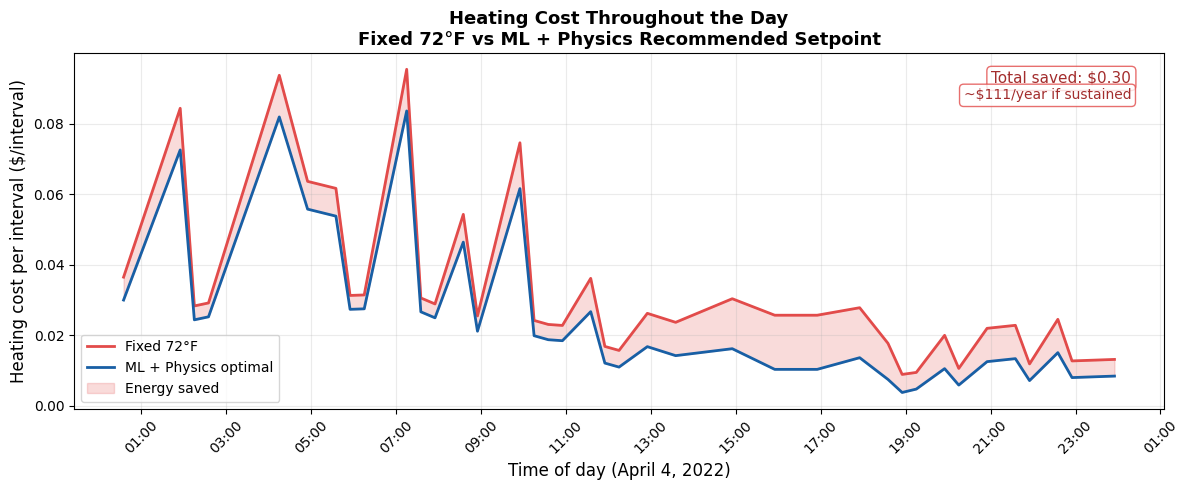

Total saved April 4: $0.30
Mean optimal setpoint: 66.3°F
Rows where optimal < 72°F: 40 / 40


In [34]:
# ── Energy cost over time: April 4 2022, weather-driven ──────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ELECTRICITY_RATE = 0.12
R_wall, A_envelope, ACH, volume = 2.3, 70, 0.5, 30

def watts_to_cost(w, interval_hours):
    return w * interval_hours / 1000 * ELECTRICITY_RATE

# Load April 2022 weather and filter to April 4
weather = pd.read_csv("Weather and Temperature Logs(April 2022).csv")
weather["timestamp"] = pd.to_datetime(weather["Time Stamp"], errors="coerce")
weather = weather.dropna(subset=["timestamp"])
weather = weather[weather["timestamp"].dt.date == pd.Timestamp("2022-04-04").date()]
weather = weather.sort_values("timestamp").reset_index(drop=True)

weather = weather.dropna(subset=["Temp (C)", "Humidity"]).reset_index(drop=True)
print(f"Rows after dropna: {len(weather)}")
print(f"Any NaN in Temp: {weather['Temp (C)'].isna().sum()}")
print(f"Any NaN in Humidity: {weather['Humidity'].isna().sum()}")
print(f"April 4 rows: {len(weather)}")

t_ext_f = ss.c_to_f(weather["Temp (C)"].values)
rh_ext  = weather["Humidity"].values / 100.0
setpoints = np.arange(65, 72.5, 0.5)
n_rows = len(weather)
n_sp   = len(setpoints)

# ── Vectorized physics across all rows × setpoints ────────────────────────────
SP   = setpoints[:, None] * np.ones((n_sp, n_rows))
TEXT = np.ones((n_sp, n_rows)) * t_ext_f[None, :]
RHEX = np.ones((n_sp, n_rows)) * rh_ext[None, :]

def hl_vec(sp, t_ext_f):
    t_int_k = (sp - 32) * 5/9 + 273.15
    t_ext_k = (t_ext_f - 32) * 5/9 + 273.15
    dT = t_int_k - t_ext_k
    return (dT / R_wall) * A_envelope + (ACH / 3600) * volume * 1.2 * 1005 * dT

def rh_vec(sp, t_ext_f, rh_ext):
    P_atm = 101.325
    def psat(tf):
        tc = (tf - 32) * 5/9
        tk = tc + 273.15
        th = tk + (-0.238555575678) / (tk - 650.175348448)
        A  = th**2 + 1167.05214528*th - 724213.167032
        B  = -17.0738469401*th**2 + 12020.8247025*th - 3232555.03223
        C  = 14.9151086135*th**2 - 4823.26573616*th + 405113.405421
        return 1000 * (2*C / (-B + np.sqrt(B**2 - 4*A*C)))**4
    pw_ext = rh_ext * psat(t_ext_f)
    W      = 0.621945 * pw_ext / (P_atm - pw_ext)
    pw_int = W * P_atm / (0.621945 + W)
    return np.clip(pw_int / psat(sp), 0, 1)

def wall_vec(sp, q_total):
    R_film   = 0.13
    t_int_k  = (sp - 32) * 5/9 + 273.15
    t_wall_k = t_int_k - (q_total * R_film / A_envelope)
    return (t_wall_k - 273.15) * 9/5 + 32

def user_q_vec(sp, rh_int, t_wall_f):
    epsilon, sigma, H, cf = 0.98, 5.6703e-8, 3.5, 0.5
    t_skin_k = 306.15
    t_wall_k = (t_wall_f - 32) * 5/9 + 273.15
    t_air_k  = (sp - 32) * 5/9 + 273.15
    q_rad    = epsilon * sigma * (t_skin_k**4 - t_wall_k**4) * cf
    q_conv   = H * (t_skin_k - t_air_k) * cf
    q_evap   = 5 * (1 - rh_int)
    return q_rad + q_conv + q_evap

HL     = hl_vec(SP, TEXT)
RH_INT = rh_vec(SP, TEXT, RHEX)
T_WALL = wall_vec(SP, HL)
USER_Q = user_q_vec(SP, RH_INT, T_WALL)
PHYS_OK = (USER_Q >= 48) & (USER_Q <= 72)

# ── Batch RF prediction ───────────────────────────────────────────────────────
feat_dict = {col: np.zeros(n_sp * n_rows) for col in X_train_enc.columns}
feat_dict["msr_indoor_temp_f"]        = SP.ravel()
feat_dict["msr_indoor_rh_frac"]       = RH_INT.ravel()
feat_dict["msr_indoor_rh_percent"]    = RH_INT.ravel() * 100
feat_dict["msr_wall_temp_f"]          = T_WALL.ravel()
feat_dict["phy_indoor_rh_frac"]       = RH_INT.ravel()
feat_dict["phy_wall_temp_f"]          = T_WALL.ravel()
feat_dict["phy_building_heat_loss_w"] = HL.ravel()
feat_dict["phy_user_heat_loss_wm2"]   = USER_Q.ravel()
feat_dict["wx_temp_c"]                = np.tile(weather["Temp (C)"].values, n_sp)
feat_dict["wx_rh_percent"]            = np.tile(weather["Humidity"].values, n_sp)
feat_dict["bld_r_wall"]               = R_wall
feat_dict["bld_a_envelope"]           = A_envelope
feat_dict["bld_ach"]                  = ACH
feat_dict["bld_volume"]               = volume

feat_df  = pd.DataFrame(feat_dict)[X_train_enc.columns].fillna(train_medians)
rf_labels = rf.predict(feat_df)
RF_OK     = (rf_labels == "Good").reshape(n_sp, n_rows)
BOTH_OK   = PHYS_OK & RF_OK

# ── Find minimum comfortable setpoint per timestamp ───────────────────────────
hl_72       = hl_vec(72, t_ext_f)
optimal_hl  = hl_72.copy()
optimal_sp  = np.full(n_rows, 72.0)

for si, sp in enumerate(setpoints):
    mask = BOTH_OK[si] & (optimal_sp == 72.0) & (sp < 72.0)
    optimal_sp[mask] = sp
    optimal_hl[mask] = HL[si][mask]

# ── Compute costs using actual intervals ──────────────────────────────────────
timestamps     = weather["timestamp"]
interval_hours = timestamps.diff().dt.total_seconds().div(3600).clip(upper=1.0).fillna(0.5).values

cost_fixed   = watts_to_cost(hl_72,       interval_hours)
cost_optimal = watts_to_cost(optimal_hl,  interval_hours)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(timestamps, cost_fixed,   color="#E24B4A", linewidth=2, label="Fixed 72°F")
ax.plot(timestamps, cost_optimal, color="#185FA5", linewidth=2, label="ML + Physics optimal")
ax.fill_between(timestamps, cost_optimal, cost_fixed,
                color="#E24B4A", alpha=0.2, label="Energy saved")

total_saved = np.nansum(cost_fixed - cost_optimal)
ax.annotate(f"Total saved: ${total_saved:.2f}",
            xy=(0.97, 0.95), xycoords="axes fraction",
            ha="right", va="top", fontsize=11, color="#A32D2D",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#E24B4A", alpha=0.8))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel("Time of day (April 4, 2022)", fontsize=12)
ax.set_ylabel("Heating cost per interval ($/interval)", fontsize=12)
ax.set_title("Heating Cost Throughout the Day\nFixed 72°F vs ML + Physics Recommended Setpoint",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
annual = total_saved * 365
ax.annotate(f"~${annual:.0f}/year if sustained",
            xy=(0.97, 0.87), xycoords="axes fraction",
            ha="right", fontsize=10, color="#A32D2D",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#E24B4A", alpha=0.8))
plt.tight_layout()
plt.savefig("energy_cost_april4.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total saved April 4: ${total_saved:.2f}")
print(f"Mean optimal setpoint: {optimal_sp.mean():.1f}°F")
print(f"Rows where optimal < 72°F: {(optimal_sp < 72).sum()} / {n_rows}")

